In [1]:
import numpy as np
import rasterio 
from rasterio.windows import Window
import xgboost as xgb
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

In [2]:
input_data_dsm = '/home/ml_user/script/Training_cnn/src/data/gujarath_dsm_RGBZ.tif'
input_data_dtm = '/home/ml_user/script/Training_cnn/src/data/gujarath_dtm_RGBZ_filled.tif'

In [3]:
def extract_features(dsm_patch, dtm_patch=None):
    """
    Convert a (H, W, 4) patch into a flat feature vector per pixel.
    Features per pixel:
        R, G, B, DSM                          (4 raw values)
        DSM mean, std, min, max (local)       (4 neighborhood stats)
        slope_x, slope_y                      (2 gradient features)
    Total: 10 features per pixel
    """
    H, W, _ = dsm_patch.shape

    r   = dsm_patch[:, :, 0]
    g   = dsm_patch[:, :, 1]
    b   = dsm_patch[:, :, 2]
    dsm = dsm_patch[:, :, 3]

    # ── Local neighborhood stats (3x3 window) ──
    from scipy.ndimage import uniform_filter, generic_filter
    dsm_mean = uniform_filter(dsm, size=3)
    dsm_std  = generic_filter(dsm, np.std,  size=3)
    dsm_min  = generic_filter(dsm, np.min,  size=3)
    dsm_max  = generic_filter(dsm, np.max,  size=3)

    # ── Gradient (slope proxy) ──
    grad_x, grad_y = np.gradient(dsm)

    # ── Stack all features: (H, W, 10) ──
    features = np.stack([
        r, g, b,
        dsm,
        dsm_mean, dsm_std, dsm_min, dsm_max,
        grad_x, grad_y
    ], axis=-1)

    # Flatten to (H*W, 10)
    X_flat = features.reshape(-1, features.shape[-1])

    if dtm_patch is not None:
        y_flat = dtm_patch[:, :, 0].reshape(-1)   # (H*W,)
        return X_flat, y_flat

    return X_flat

In [4]:
def collect_xgb_data(
    dsm_path,
    dtm_path,
    patch_size           = 64,    # smaller patches for XGBoost (memory)
    stride               = 64,
    max_patches          = 500,   # limit total patches — XGB doesn't need millions
    dtm_nodata_threshold = 60000
):
    with rasterio.open(dsm_path) as dsm_src, rasterio.open(dtm_path) as dtm_src:
        H, W       = dsm_src.height, dsm_src.width
        nodata_dsm = dsm_src.nodata
        nodata_dtm = dtm_src.nodata

        # ── Compute normalization stats ──
        dsm_full = dsm_src.read(4).astype(np.float32)
        dtm_full = dtm_src.read(1).astype(np.float32)

        if nodata_dsm is not None: dsm_full[dsm_full == nodata_dsm] = np.nan
        if nodata_dtm is not None: dtm_full[dtm_full == nodata_dtm] = np.nan
        dsm_full[dsm_full < -50]                   = np.nan
        dtm_full[dtm_full >= dtm_nodata_threshold] = np.nan

        dsm_min, dsm_max = float(np.nanmin(dsm_full)), float(np.nanmax(dsm_full))
        dtm_min, dtm_max = float(np.nanmin(dtm_full)), float(np.nanmax(dtm_full))

        print(f"DSM range : {dsm_min:.2f} → {dsm_max:.2f}")
        print(f"DTM range : {dtm_min:.2f} → {dtm_max:.2f}")
        del dsm_full, dtm_full

        # ── Collect patches ──
        coords = [
            (y, x)
            for y in range(0, H - patch_size + 1, stride)
            for x in range(0, W - patch_size + 1, stride)
        ]
        np.random.shuffle(coords)
        coords = coords[:max_patches]       # limit patches
        print(f"Collecting {len(coords)} patches...")

        X_all, y_all = [], []

        for idx, (cy, cx) in enumerate(coords):
            window = Window(cx, cy, patch_size, patch_size)
            dsm    = dsm_src.read(window=window).astype(np.float32)
            dtm    = dtm_src.read(1, window=window).astype(np.float32)

            # Mask nodata
            if nodata_dsm is not None: dsm[dsm == nodata_dsm] = np.nan
            if nodata_dtm is not None: dtm[dtm == nodata_dtm] = np.nan
            dsm[dsm < -50]                   = np.nan
            dtm[dtm >= dtm_nodata_threshold] = np.nan

            # Skip bad patches
            if np.isnan(dsm[3]).any() or np.isnan(dtm).any(): continue
            if np.isnan(dsm[:3]).any() or (dsm[:3] < 0).any(): continue
            if np.isinf(dsm).any()     or np.isinf(dtm).any(): continue

            X_patch = np.transpose(dsm[:4], (1, 2, 0)).copy()
            y_patch = dtm[..., np.newaxis].copy()

            # Normalize
            X_patch[:, :, :3] = np.clip(X_patch[:, :, :3], 0, 255) / 255.0
            X_patch[:, :,  3] = (X_patch[:, :, 3] - dsm_min) / (dsm_max - dsm_min + 1e-8)
            y_patch           = (y_patch - dtm_min) / (dtm_max - dtm_min + 1e-8)
            X_patch           = np.clip(X_patch, 0.0, 1.0)
            y_patch           = np.clip(y_patch, 0.0, 1.0)

            if np.isnan(X_patch).any() or np.isnan(y_patch).any(): continue

            # Extract flat features
            X_flat, y_flat = extract_features(X_patch, y_patch)

            X_all.append(X_flat)
            y_all.append(y_flat)

            if (idx + 1) % 50 == 0:
                print(f"  {idx+1}/{len(coords)} patches collected")

        X_all = np.vstack(X_all)    # (N_pixels, 10)
        y_all = np.hstack(y_all)    # (N_pixels,)

        print(f"\nDataset shape : X={X_all.shape}  y={y_all.shape}")
        print(f"y range       : {y_all.min():.4f} → {y_all.max():.4f}")

        return X_all, y_all, (dsm_min, dsm_max, dtm_min, dtm_max)

In [5]:
def train_xgboost(X, y):

    # Train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"Train : {X_train.shape}  Val : {X_val.shape}")

    # Build DMatrix (XGBoost's optimised data format)
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val,   label=y_val)

    params = {
        'objective'        : 'reg:squarederror',
        'eval_metric'      : 'mae',
        'max_depth'        : 6,          # tree depth
        'learning_rate'    : 0.05,       # shrinkage
        'n_estimators'     : 500,
        'subsample'        : 0.8,        # row sampling
        'colsample_bytree' : 0.8,        # feature sampling
        'min_child_weight' : 5,
        'gamma'            : 0.1,
        'tree_method'      : 'hist',     # fast histogram method
        'device'           : 'cuda',     # GPU acceleration
        'verbosity'        : 1
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round = 500,
        evals           = [(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds = 20,
        verbose_eval    = 50
    )

    return model, X_val, y_val

In [6]:
def evaluate_xgboost(model, X_val, y_val):

    dval   = xgb.DMatrix(X_val)
    y_pred = model.predict(dval)

    mae  = mean_absolute_error(y_val, y_pred)
    mse  = mean_squared_error(y_val,  y_pred)
    r2   = r2_score(y_val, y_pred)

    print("\n── XGBoost Evaluation ──")
    print(f"  MAE  : {mae:.6f}")
    print(f"  MSE  : {mse:.6f}")
    print(f"  RMSE : {np.sqrt(mse):.6f}")
    print(f"  R²   : {r2:.6f}")

    # Health check
    if r2 > 0.95:
        print("  ✅  EXCELLENT — R² > 0.95")
    elif r2 > 0.85:
        print("  ✅  GOOD      — R² > 0.85")
    elif r2 > 0.70:
        print("  🟡  OK        — R² > 0.70")
    else:
        print("  ❌  POOR      — check features or data")

    # ── Plots ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Scatter — GT vs Pred
    axes[0].scatter(y_val, y_pred, alpha=0.05, s=1, color='steelblue')
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
    axes[0].set_title(f'GT vs Predicted  (R²={r2:.4f})')
    axes[0].set_xlabel('Ground Truth')
    axes[0].set_ylabel('Predicted')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Error distribution
    errors = np.abs(y_val - y_pred)
    axes[1].hist(errors, bins=50, color='darkorange', edgecolor='white')
    axes[1].set_title(f'Error Distribution  (MAE={mae:.4f})')
    axes[1].set_xlabel('Absolute Error')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)

    # Feature importance
    importance = model.get_score(importance_type='gain')
    feat_names = ['R', 'G', 'B', 'DSM', 'DSM_mean',
                  'DSM_std', 'DSM_min', 'DSM_max', 'grad_x', 'grad_y']
    imp_vals   = [importance.get(f'f{i}', 0) for i in range(len(feat_names))]
    axes[2].barh(feat_names, imp_vals, color='steelblue')
    axes[2].set_title('Feature Importance (Gain)')
    axes[2].set_xlabel('Importance')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('xgb_evaluation.png', dpi=150)
    plt.show()

    return y_pred

In [7]:
def save_xgb_model(model, stats, path='xgb_dtm_model'):
    Path(path).mkdir(exist_ok=True)
    model.save_model(f'{path}/xgb_model.json')         # model
    joblib.dump(stats, f'{path}/norm_stats.pkl')        # normalization stats
    print(f"Model saved → {path}/xgb_model.json")
    print(f"Stats saved → {path}/norm_stats.pkl")


def load_xgb_model(path='xgb_dtm_model'):
    model = xgb.Booster()
    model.load_model(f'{path}/xgb_model.json')
    stats = joblib.load(f'{path}/norm_stats.pkl')
    print("Model loaded successfully")
    return model, stats


DSM range : -31.35 → 17.16
DTM range : 771.00 → 59999.62
  400/500 patches collected

Dataset shape : X=(430080, 10)  y=(430080,)
y range       : 0.1056 → 0.9589
Train : (344064, 10)  Val : (86016, 10)
[0]	train-mae:0.10402	val-mae:0.10373


/home/ml_user/anaconda3/envs/geo-ai/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [14:14:46] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/home/ml_user/anaconda3/envs/geo-ai/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [14:14:46] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-mae:0.08607	val-mae:0.08591
[100]	train-mae:0.08402	val-mae:0.08399
[150]	train-mae:0.08316	val-mae:0.08319
[200]	train-mae:0.08291	val-mae:0.08297
[250]	train-mae:0.08287	val-mae:0.08294
[277]	train-mae:0.08286	val-mae:0.08293

── XGBoost Evaluation ──
  MAE  : 0.082934
  MSE  : 0.012154
  RMSE : 0.110245
  R²   : 0.337298
  ❌  POOR      — check features or data


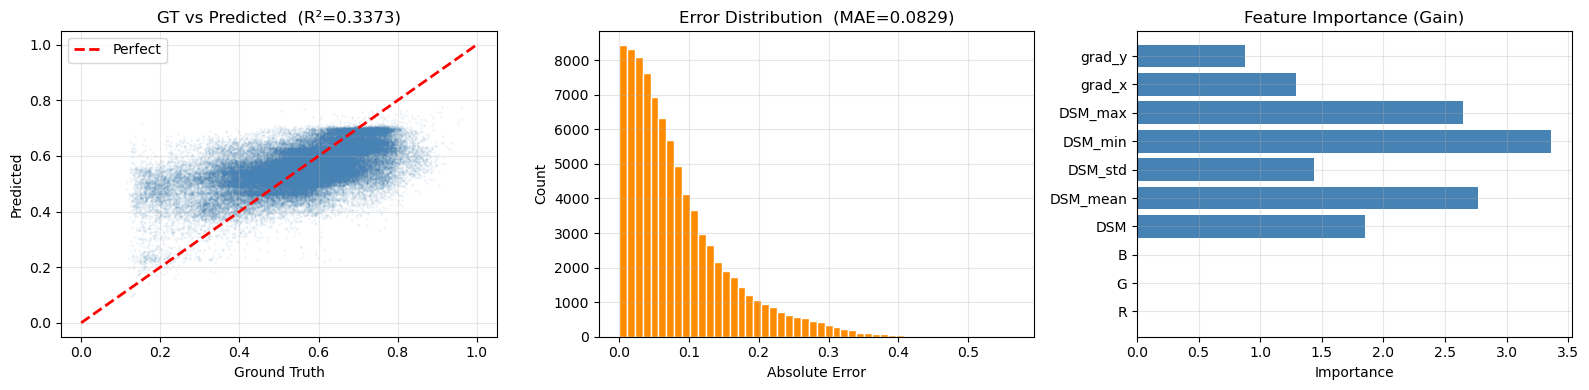

Model saved → xgb_dtm_model/xgb_model.json
Stats saved → xgb_dtm_model/norm_stats.pkl


In [8]:
X, y, stats = collect_xgb_data(
    dsm_path    = input_data_dsm,
    dtm_path    = input_data_dtm,
    patch_size  = 64,
    stride      = 64,
    max_patches = 500
)

# Step 2 — train
model_xgb, X_val, y_val = train_xgboost(X, y)

# Step 3 — evaluate
y_pred = evaluate_xgboost(model_xgb, X_val, y_val)

# Step 4 — save
save_xgb_model(model_xgb, stats)